# Flood Risk in Europe

### Economic Losses, Human Impact and Climate Risk Analysis using EM-DAT (2000–2026)


## Project Overview

This project analyses historical flood events across Europe using the EM-DAT International Disaster Database to assess physical flood risk through economic losses, human impacts and insurance protection gaps. The findings are intended to support climate risk assessment, infrastructure planning and insurance decision-making.


## Business Objective

Assess historical flood impacts across Europe (2000–2026) to identify patterns in economic losses, human impacts and insurance protection gaps. The analysis aims to support climate risk assessment and provide insights relevant to insurers, governments and infrastructure planning.

## Key Questions

- Which countries experience the highest flood losses?
- How have flood impacts evolved over time?
- Where are the largest insurance gaps?
- Which flood types are the most damaging?
- What indicators are most relevant for climate risk assessment?


## Objectives

- Quantify cumulative economic losses from flood events by country (2000–2026)
- Analyse the insurance protection gap across European markets
- Identify mortality patterns and vulnerability profiles by country
- Compare risk profiles across flood subtypes (riverine, flash, coastal, general)
- Identify the most catastrophic individual flood events
- Visualise spatial distribution of flood economic damage across Europe
- Normalise economic losses by GDP to assess relative country exposure


## Data Source

- **EM-DAT** - The International Disaster Database (CRED, UCLouvain). Dataset: Flood events in Europe, 2000-2026. All damage figures adjusted to constant USD using CPI deflation. Access: [public.emdat.be](https://public.emdat.be) (registration required)
- **Natural Earth** - Country boundaries shapefile (110m resolution). Access: [naturalearthdata.com](https://www.naturalearthdata.com/downloads/110m-cultural-vectors/)
- **World Bank** - GDP data (NY.GDP.MKTP.CD), average 2000-2024. Access: [data.worldbank.org](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD)


## Tools and Libraries
Python · Pandas · Matplotlib · GeoPandas · NumPy · SciPy · World Bank Data

## Table of Contents

1. [Data Loading](#Data-Loading)
2. [Data Cleaning](#Data-Cleaning-and-Preparation)
3. [Exploratory Analysis](#Exploratory-Analysis:-Economic-Losses)
4. [GDP Normalisation](#GDP-Normalisation)
5. [Trend Analysis](#Trend-Analysis)
6. [Insurance Protection Gap](#Insurance-Gap-Analysis)
7. [Mortality Analysis](#Mortality-Analysis)
8. [Population Impact Analysis](#Population-Impact-Analysis)
9. [Vulnerability Analysis](#Vulnerability-Analysis)
10. [Flood Type Analysis](#Flood-Type-Analysis)
11. [Mortality by Flood Type](#Mortality-by-Flood-Type)
12. [Extreme Events](#Extreme-Events)
13. [Geographic Analysis](#Geographic-Analysis)
14. [Business Implications](#Business-and-Policy-Implications)
15. [Key Findings](#Key-Findings-and-Climate-Risk-Implications)
16. [Conclusions](#Conclusions)
17. [Limitations](#Limitations-and-Future-Work)

## Data Loading

In [1]:
# --- IMPORTS ---
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import geopandas

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

from scipy import stats

In [2]:
def plot_ranked_barh(data, title, xlabel, fname, cmap=cm.YlOrRd, value_fmt="{:.1f}", value_prefix="", value_suffix="", xaxis_fmt=None, label_offset=None, figsize=(12, 6)):
    sorted_data = data.sort_values()
    norm = plt.Normalize(sorted_data.min(), sorted_data.max())
    colors = cmap(norm(sorted_data.values))
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.barh(sorted_data.index, sorted_data.values, color=colors, edgecolor="gray", linewidth=0.5)
    labels = [f"{value_prefix}{value_fmt.format(v)}{value_suffix}" for v in sorted_data.values]
    ax.bar_label(bars, labels=labels, padding=3, fontsize=9)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    if xaxis_fmt is not None:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(xaxis_fmt))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    return fig, ax

**Available columns** in the raw dataset, followed by a **preview of the key columns** selected for analysis.

In [3]:
#Load the EM-DAT flood dataset and perform an initial inspection of its structure, dimensions and key variables before data cleaning.

df = pd.read_excel("../data/emdat_floods_europe.xlsx", sheet_name="EM-DAT Data")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(pd.DataFrame(df.columns.tolist(), columns=["Column Name"]))

display(df[["Country", "Start Year", "Total Deaths", "Total Damage ('000 US$)", "Insured Damage ('000 US$)"]].head(10))

Dataset shape: 493 rows × 47 columns


,Column Name
0,DisNo.
1,Historic
2,Classification Key
3,Disaster Group
4,Disaster Subgroup
5,Disaster Type
6,Disaster Subtype
7,External IDs
8,Event Name
9,ISO


,Country,Start Year,Total Deaths,Total Damage ('000 US$),Insured Damage ('000 US$)
0,Russian Federation,2026,6.0,NaN,NaN
1,Bosnia and Herzegovina,2020,NaN,NaN,NaN
2,France,2019,3.0,NaN,NaN
3,Greece,2020,NaN,NaN,NaN
4,Bulgaria,2021,NaN,NaN,NaN
5,Serbia,2021,NaN,NaN,NaN
6,Italy,2019,NaN,NaN,NaN
7,Romania,2021,1.0,NaN,NaN
8,Belgium,2021,39.0,2000000.0,NaN
9,Czechia,2021,NaN,NaN,NaN


**Dataset Overview**

In [4]:
summary = pd.DataFrame({
    "Metric": [
        "Total records",
        "Records with Total Damage",
        "Records with Insured Damage",
        "Records with Total Deaths",
        "Unique countries",
        "Years available"
    ],
    "Value": [
        len(df),
        df["Total Damage ('000 US$)"].notna().sum(),
        df["Insured Damage ('000 US$)"].notna().sum(),
        df["Total Deaths"].notna().sum(),
        df["Country"].nunique(),
        f"{df['Start Year'].min()} - {df['Start Year'].max()}"
    ]
})

display(summary)


,Metric,Value
0,Total records,493
1,Records with Total Damage,180
2,Records with Insured Damage,50
3,Records with Total Deaths,272
4,Unique countries,36
5,Years available,2000 - 2026


**Note on 2026 data:** The dataset includes partial-year records for 2026 (data available only through mid-2026). Cumulative and ranking tables throughout this notebook (e.g. total damage, deaths and people affected by country) use all available records, including this incomplete 2026 data, to reflect the most up-to-date picture. The Trend Analysis section below restricts its time-series calculations to complete years (2000-2024) to avoid distorting year-over-year comparisons with a partial final year.

## Data Cleaning and Preparation

In [5]:
# --- DATA CLEANING AND PREPARATION ---

# Select relevant columns
cols = [
    "Country", "Subregion", "ISO", "Disaster Subtype",
    "Start Year", "Start Month",
    "Total Deaths", "No. Affected", "Total Affected",
    "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)",
    "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)"
]

df_clean = df[cols].copy()

# Rename columns for easier use
df_clean.columns = [
    "country", "subregion", "iso", "flood_type",
    "year", "month",
    "total_deaths", "no_affected", "total_affected",
    "total_damage", "total_damage_adj",
    "insured_damage", "insured_damage_adj"
]

# Shorten a few long official country names for readability in charts/tables
country_rename = {
    "United Kingdom of Great Britain and Northern Ireland": "UK",
    "Russian Federation": "Russia",
    "Bosnia and Herzegovina": "Bosnia",
    "Netherlands (Kingdom of the)": "Netherlands",
    "Republic of Moldova": "Moldova",
}
df_clean["country"] = df_clean["country"].replace(country_rename)

**Column types**

In [6]:
print(f"Cleaned dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns")
display(df_clean.dtypes.to_frame(name="Data Type"))

Cleaned dataset: 493 rows x 13 columns


,Data Type
country,str
subregion,str
iso,str
flood_type,str
year,int64
month,int64
total_deaths,float64
no_affected,float64
total_affected,float64
total_damage,float64


**Missing values per column**

In [7]:
# Check missing values
display(df_clean.isnull().sum().to_frame(name="Missing Values"))

,Missing Values
country,0
subregion,0
iso,0
flood_type,0
year,0
month,0
total_deaths,221
no_affected,81
total_affected,68
total_damage,313


**Data availability by key variable**

In [8]:
# Missing values are expected in damage columns
# Not all disaster events have complete economic reporting
# We will work with available data and flag missing values where relevant

display(pd.DataFrame({
    "Variable": ["Total Damage", "Insured Damage", "Total Deaths"],
    "Records Available": [
        df_clean["total_damage"].notna().sum(),
        df_clean["insured_damage"].notna().sum(),
        df_clean["total_deaths"].notna().sum()
    ],
    "Total Records": [len(df_clean)] * 3,
    "Coverage": [
        f"{df_clean['total_damage'].notna().mean():.0%}",
        f"{df_clean['insured_damage'].notna().mean():.0%}",
        f"{df_clean['total_deaths'].notna().mean():.0%}"
    ]
}))

,Variable,Records Available,Total Records,Coverage
0,Total Damage,180,493,37%
1,Insured Damage,50,493,10%
2,Total Deaths,272,493,55%


**Average GDP by country 2000-2024 (Billion USD) - preview**

In [9]:
# --- LOAD GDP DATA ---

gdp_raw = pd.read_csv("../data/external/API_NY.GDP.MKTP.CD_DS2_en_csv_v2_4569.csv", skiprows=4)

# Keep only relevant columns
years = [str(y) for y in range(2000, 2025)]
gdp_long = gdp_raw[["Country Code"] + years].melt(
    id_vars="Country Code",
    var_name="year",
    value_name="gdp"
)
gdp_long.columns = ["iso", "year", "gdp"]
gdp_long["year"] = gdp_long["year"].astype(int)
gdp_long["gdp"] = pd.to_numeric(gdp_long["gdp"], errors="coerce")

# Average GDP per country over 2000-2024
gdp_avg = gdp_long.groupby("iso")["gdp"].mean().reset_index()
gdp_avg.columns = ["iso", "gdp_avg_usd"]
gdp_avg["gdp_avg_bn"] = (gdp_avg["gdp_avg_usd"] / 1e9).round(1)

display(gdp_avg[["iso", "gdp_avg_bn"]].head(10).rename(columns={"iso": "ISO", "gdp_avg_bn": "Avg GDP (Billion USD)"}))
print(f"\nCountries with GDP data: {gdp_avg['gdp_avg_usd'].notna().sum()}")

,ISO,Avg GDP (Billion USD)
0,ABW,2.7
1,AFE,804.2
2,AFG,13.4
3,AFW,628.7
4,AGO,79.9
5,ALB,12.5
6,AND,3.1
7,ARB,2247.4
8,ARE,325.2
9,ARG,419.9



Countries with GDP data: 261


## Exploratory Analysis: Economic Losses

**Which European countries have suffered the greatest cumulative flood losses since 2000?**

**Total Adjusted Flood Damage by Country - Cumulative 2000-2026** (Billion USD)

In [10]:
# --- EXPLORATORY DATA ANALYSIS ---

# Total economic damage by country (top 15)
damage_by_country = (
    df_clean.groupby("country")["total_damage_adj"]
    .sum(min_count=1)
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

damage_count = df_clean[df_clean["total_damage_adj"].notna()].groupby("country").size()
total_count = df_clean.groupby("country").size()

result = (damage_by_country / 1e6).round(1).to_frame(name="Total Damage (Billion USD)")
result["Events with Damage Data"] = damage_count
result["Total Events"] = total_count
result["Coverage"] = (result["Events with Damage Data"] / result["Total Events"]).map("{:.0%}".format)

display(result)

,Total Damage (Billion USD),Events with Damage Data,Total Events,Coverage
country,,,,
Germany,93.8,7,12,58%
UK,34.3,14,28,50%
Italy,32.0,22,36,61%
Spain,16.6,13,24,54%
France,15.8,14,43,33%
Austria,7.1,4,10,40%
Czechia,6.4,7,14,50%
Poland,6.0,3,10,30%
Russia,5.5,32,56,57%


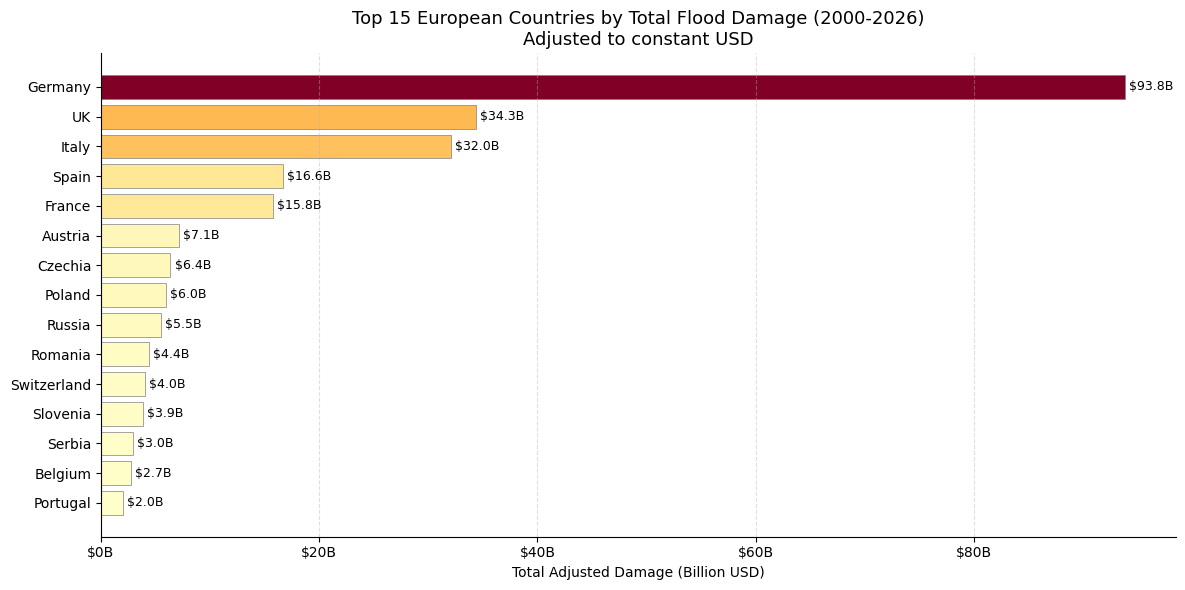

In [11]:
# Bar chart: Top 15 countries by total adjusted flood damage
damage_by_country_b = damage_by_country / 1e6

plot_ranked_barh(damage_by_country_b, "Top 15 European Countries by Total Flood Damage (2000-2026)\nAdjusted to constant USD", "Total Adjusted Damage (Billion USD)", "../images/01_damage_by_country.png", value_prefix="$", value_suffix="B", xaxis_fmt=lambda x, _: f"${x:.0f}B");

Germany dominates cumulative flood losses by a wide margin, accounting for nearly 38% of total recorded damage across Europe. This is largely explained by a single catastrophic event: the 2021 Ahr Valley floods, which alone caused an estimated 47.5B USD in damage - the costliest natural disaster in German history.

The gap between Germany and the rest of Europe is striking. The UK and Italy, ranked second and third, together account for 66.3B USD in recorded damage - around 70% of Germany's losses alone, despite being two separate countries with their own distinct flood histories. This pattern illustrates a key principle in catastrophe risk: aggregate losses are often driven by a handful of extreme, low-frequency events rather than by the accumulation of smaller ones.

From an insurance and climate risk perspective, this concentration of losses in a small number of countries and events has important implications for capital allocation, reinsurance pricing and physical risk disclosure.

## GDP Normalisation

**Flood Damage Normalized by Average GDP (2000-2024)**

In [12]:
# --- DAMAGE NORMALIZED BY GDP ---

# Merge damage by country with GDP data
damage_gdp = (damage_by_country / 1e6).round(1).to_frame(name="Total Damage (B USD)")
damage_gdp.index.name = "country"
damage_gdp = damage_gdp.reset_index()

# Get ISO codes for merging
iso_map = df_clean[["country", "iso"]].drop_duplicates()
damage_gdp = damage_gdp.merge(iso_map, on="country")
damage_gdp = damage_gdp.merge(gdp_avg[["iso", "gdp_avg_bn"]], on="iso")

# Calculate damage as % of average GDP
damage_gdp["Damage as % of GDP"] = (damage_gdp["Total Damage (B USD)"] / damage_gdp["gdp_avg_bn"] * 100).round(2)
damage_gdp = damage_gdp.sort_values("Damage as % of GDP", ascending=False)

display(damage_gdp[["country", "Total Damage (B USD)", "gdp_avg_bn", "Damage as % of GDP"]].rename(columns={
    "country": "Country",
    "gdp_avg_bn": "Avg GDP (B USD)"
}).reset_index(drop=True))

,Country,Total Damage (B USD),Avg GDP (B USD),Damage as % of GDP
0,Slovenia,3.9,46.3,8.42
1,Serbia,3.0,45.3,6.62
2,Czechia,6.4,203.6,3.14
3,Germany,93.8,3491.2,2.69
4,Romania,4.4,183.9,2.39
5,Austria,7.1,385.7,1.84
6,Italy,32.0,1970.5,1.62
7,Spain,16.6,1283.1,1.29
8,UK,34.3,2699.0,1.27
9,Poland,6.0,482.5,1.24


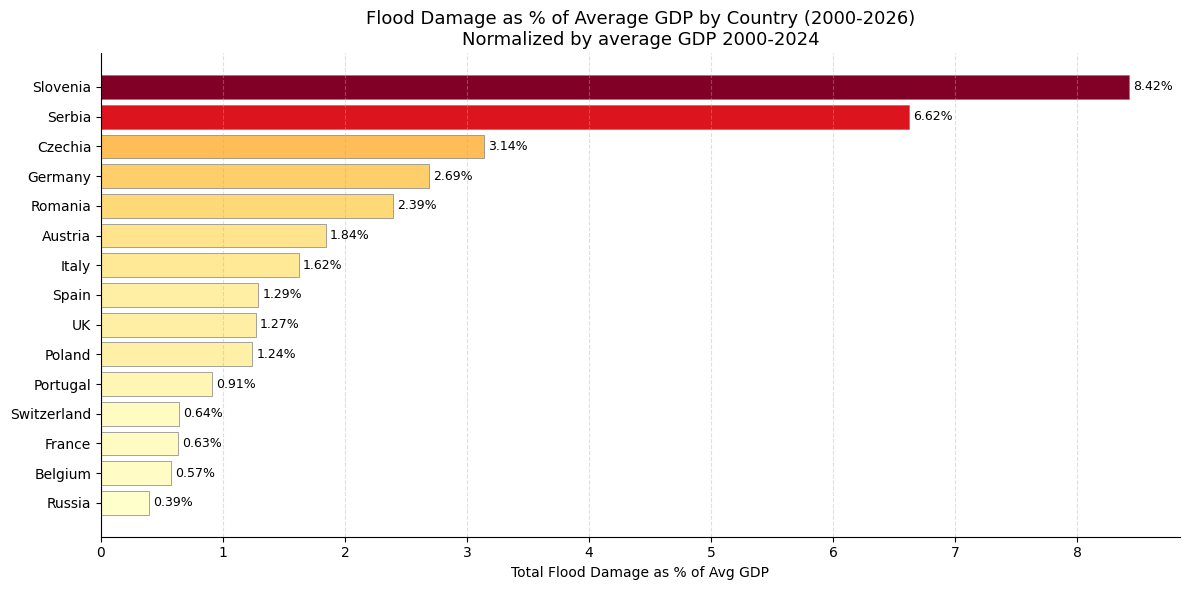

In [13]:
# Bar chart: Flood damage as % of average GDP
gdp_pct_series = damage_gdp.set_index("country")["Damage as % of GDP"]

plot_ranked_barh(gdp_pct_series, "Flood Damage as % of Average GDP by Country (2000-2026)\nNormalized by average GDP 2000-2024", "Total Flood Damage as % of Avg GDP", "../images/02_damage_normalized_gdp.png", value_fmt="{:.2f}", value_suffix="%");

When flood losses are normalised by economic size, the picture changes dramatically. Slovenia and Serbia, which appear modest in absolute terms, emerge as the most exposed countries relative to their GDP. This highlights the importance of economic context when assessing flood risk: a smaller economy can be severely impacted by losses that would be manageable for a larger one.

Germany drops to 4th place despite having the highest absolute losses, reflecting its much larger economic base. This normalised view is more relevant for assessing sovereign fiscal risk and insurance market depth.

While cumulative losses identify the countries most affected overall, they do not reveal how flood impacts have evolved over time. The following section explores temporal trends in both event frequency and economic damage.

## Trend Analysis

**Is the frequency of flood events in Europe increasing over time?**

In [14]:
# Note: 2026 is incomplete (data only up to June 2026)
# 2022 may also be underreported due to data validation lag
# Trend analysis should focus on 2000-2024 for completeness

df_trend = df_clean[df_clean["year"] <= 2024].copy()
print(f"Records used for trend analysis (2000-2024): {len(df_trend)}")

Records used for trend analysis (2000-2024): 486


Linear trend: R² = 0.227, p-value = 0.016


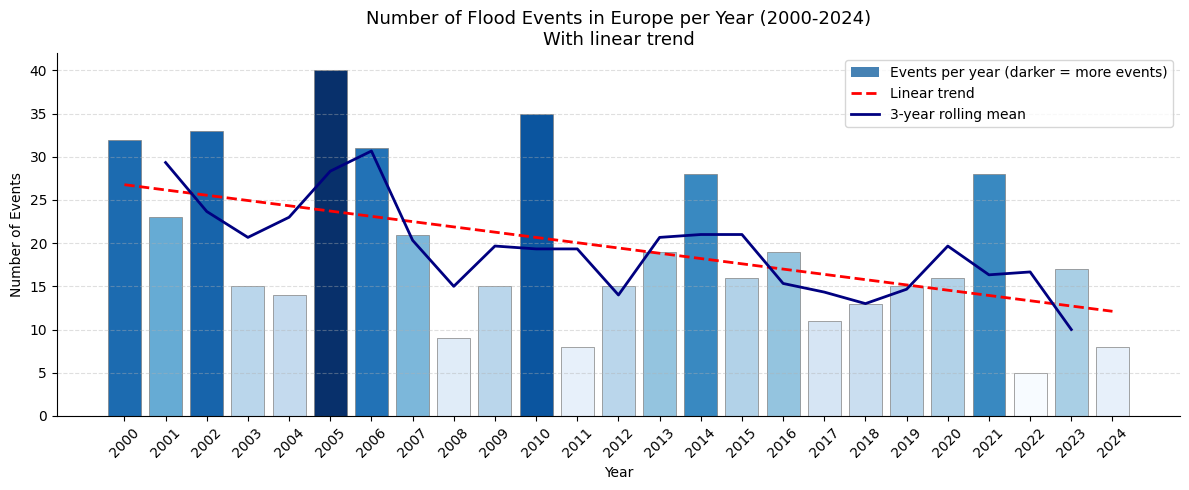

In [15]:
# Number of flood events per year with trend line (2000-2024)
events_per_year_trend = df_trend.groupby("year").size()

# Calculate trend line
z = np.polyfit(events_per_year_trend.index, events_per_year_trend.values, 1)
p = np.poly1d(z)


slope, intercept, r_value, p_value, std_err = stats.linregress(events_per_year_trend.index, events_per_year_trend.values)
print(f"Linear trend: R² = {r_value**2:.3f}, p-value = {p_value:.3f}")

# Rolling mean (3-year window)
rolling_mean = events_per_year_trend.rolling(window=3, center=True).mean()

# Color gradient based on value
norm = plt.Normalize(events_per_year_trend.min(), events_per_year_trend.max())
colors = cm.Blues(norm(events_per_year_trend.values))

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(range(len(events_per_year_trend)), events_per_year_trend.values,
       color=colors, edgecolor="gray", linewidth=0.5)
ax.plot(range(len(events_per_year_trend)), p(events_per_year_trend.index),
        color="red", linewidth=2, linestyle="--")
ax.plot(range(len(events_per_year_trend)), rolling_mean.values,
        color="navy", linewidth=2, linestyle="-")

ax.set_title("Number of Flood Events in Europe per Year (2000-2024)\nWith linear trend", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Events")
ax.set_xticks(range(len(events_per_year_trend)))
ax.set_xticklabels(events_per_year_trend.index, rotation=45)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

legend_elements = [
    Patch(facecolor="steelblue", label="Events per year (darker = more events)"),
    Line2D([0], [0], color="red", linewidth=2, linestyle="--", label="Linear trend"),
    Line2D([0], [0], color="navy", linewidth=2, linestyle="-", label="3-year rolling mean")
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig("../images/03_events_per_year_trend.png", dpi=150)
plt.show()

The linear trend suggests a slight decline in the number of recorded flood events over the period. However, this should be interpreted with caution: recent years are likely underreported in EM-DAT, as data validation and entry takes time after a disaster occurs. This is a known limitation of disaster databases and should be noted when interpreting frequency trends.

What the economic damage chart reveals is a very different story: the 2021 spike dwarfs every other year in the dataset. This suggests that while event frequency may not be increasing dramatically, the severity of individual events is. A smaller number of catastrophic floods is generating a growing share of total losses, a pattern consistent with IPCC AR6 projections on the intensification of extreme weather events under climate change. Economic damage analysis using adjusted values is therefore more reliable for trend assessment than raw event frequency alone.

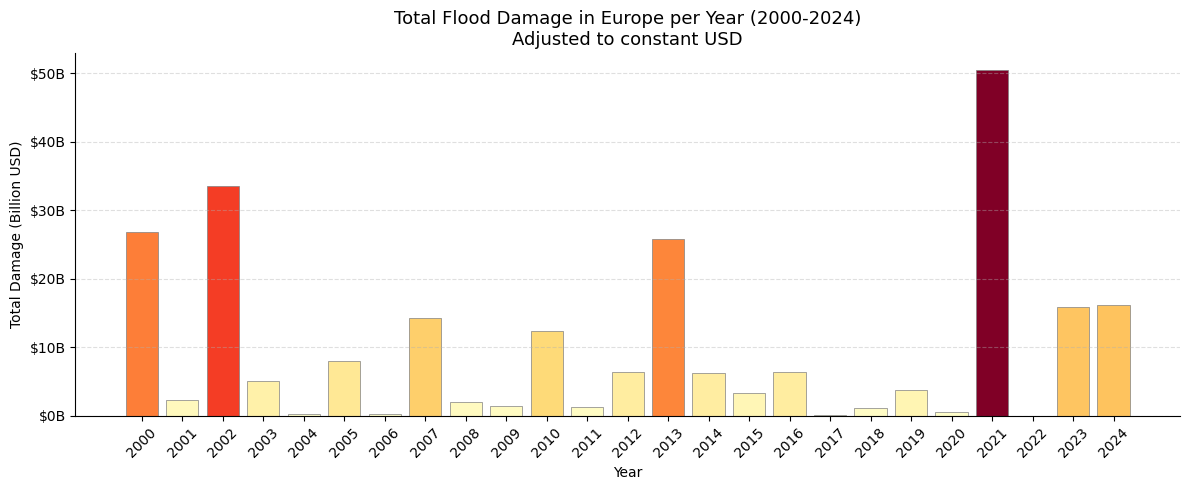

In [16]:
# --- ECONOMIC DAMAGE TREND OVER TIME ---
# Total adjusted flood damage per year (2000-2024)
damage_per_year = (
    df_trend.groupby("year")["total_damage_adj"]
    .sum()
    / 1e6
)

norm = plt.Normalize(damage_per_year.min(), damage_per_year.max())
colors = cm.YlOrRd(norm(damage_per_year.values))

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(range(len(damage_per_year)), damage_per_year.values,
       color=colors, edgecolor="gray", linewidth=0.5)

ax.set_title("Total Flood Damage in Europe per Year (2000-2024)\nAdjusted to constant USD", fontsize=13)
ax.set_xlabel("Year")
ax.set_ylabel("Total Damage (Billion USD)")
ax.set_xticks(range(len(damage_per_year)))
ax.set_xticklabels(damage_per_year.index, rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../images/04_damage_per_year.png", dpi=150)
plt.show()

The 2021 spike is unmistakable: a single year accounts for a disproportionate share of total flood losses across the entire 25-year period, driven by the catastrophic Ahr Valley floods in Germany. Quantifying this concentration: 2021 alone represents 20.6% of all adjusted flood damage recorded between 2000 and 2024 - a measure of concentration in a single extreme year rather than a linear trend, and a more precise way to state this pattern than a visual impression alone. Secondary peaks in 2000, 2002 and 2013 correspond to major riverine flood events across Central Europe.

The years with near-zero damage are not necessarily years without floods. They reflect the underreporting and data gaps already noted, particularly for smaller or less documented events. This reinforces the importance of working with adjusted values and treating aggregate statistics with appropriate caution.

## Insurance Gap Analysis

**How much of the total flood damage in Europe is actually covered by insurance?**


> **Note:** The damage figures in this table reflect only events where both total damage and insured damage data are available. This is a stricter subset than the figures shown in the Exploratory Analysis section, which include all events with any damage data recorded.
>
> **This subset is not interchangeable with the Exploratory Analysis totals.** For some countries the difference is negligible after rounding (Germany: 93.81B vs 93.78B, a 30M USD gap from a single small 2009 event; Switzerland and Portugal: 0% difference). For most other countries, however, restricting to events with insurance data removes a substantial share of total damage: UK -7%, Spain -4%, Austria -4%, Czechia -12%, France -19%, Italy -46%, Poland -79%, Russia -83%, and Romania -100% (no insured events recorded at all). These reductions reflect gaps in insurance reporting, not necessarily the true absence of insurance coverage, but they mean the Insurance Gap table below should be read as a narrower, differently-composed subset of events rather than a simple insured/uninsured split of the totals shown earlier in this notebook.

**Insurance Gap by Country - Top 10** (Billion USD)

In [17]:
# --- INSURANCE GAP ANALYSIS ---

# Compare total damage vs insured damage by country
# Insurance gap = total damage - insured damage (uninsured losses)
gap_data = (
    df_clean.dropna(subset=["total_damage_adj", "insured_damage_adj"])
    .groupby("country")[["total_damage_adj", "insured_damage_adj"]]
    .sum()
    .sort_values("total_damage_adj", ascending=False)
    .head(10)
    / 1e6
)
gap_data["insurance_gap"] = gap_data["total_damage_adj"] - gap_data["insured_damage_adj"]

total_count = df_clean.groupby("country").size()
insured_count = df_clean[df_clean["insured_damage_adj"].notna()].groupby("country").size().reindex(total_count.index, fill_value=0)

gap_data["Events with Insured Data"] = insured_count
gap_data["Total Events"] = total_count
gap_data["Coverage"] = (gap_data["Events with Insured Data"] / gap_data["Total Events"]).map("{:.0%}".format)

display(gap_data[["total_damage_adj", "insured_damage_adj", "insurance_gap", "Events with Insured Data", "Total Events", "Coverage"]].round(1).rename(columns={
    "total_damage_adj": "Total Damage (B USD)",
    "insured_damage_adj": "Insured Damage (B USD)",
    "insurance_gap": "Insurance Gap (B USD)"
}))

,Total Damage (B USD),Insured Damage (B USD),Insurance Gap (B USD),Events with Insured Data,Total Events,Coverage
country,,,,,,
Germany,93.8,20.5,73.3,6,12,50%
UK,31.9,14.8,17.1,10,28,36%
Italy,17.2,0.9,16.4,6,36,17%
Spain,15.9,5.7,10.2,6,24,25%
France,12.8,7.5,5.2,8,43,19%
Austria,6.8,1.3,5.6,3,10,30%
Czechia,5.6,2.8,2.8,3,14,21%
Switzerland,4.0,2.9,1.1,2,4,50%
Portugal,2.0,0.1,1.9,1,6,17%


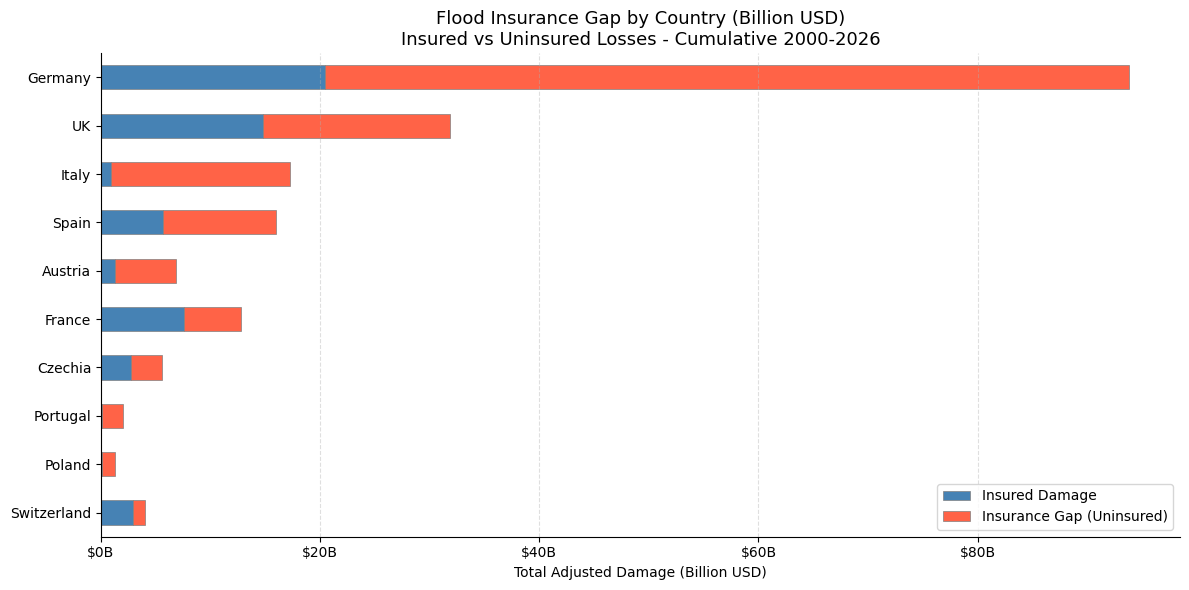

In [18]:
# Stacked bar chart: insured vs uninsured damage by country
fig, ax = plt.subplots(figsize=(12, 6))

gap_data[["insured_damage_adj", "insurance_gap"]].sort_values("insurance_gap").plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["steelblue", "tomato"],
    edgecolor="gray",
    linewidth=0.5
)

ax.set_title("Flood Insurance Gap by Country (Billion USD)\nInsured vs Uninsured Losses - Cumulative 2000-2026", fontsize=13)
ax.set_xlabel("Total Adjusted Damage (Billion USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.legend(["Insured Damage", "Insurance Gap (Uninsured)"], loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../images/05_insurance_gap.png", dpi=150)
plt.show()

The insurance protection gap across Europe is striking. Germany, despite having the most developed insurance market among the affected countries, still left 73.3B USD uninsured - nearly 78% of total losses. This underlines that even in wealthy, well-regulated markets, flood insurance penetration remains insufficient.

Italy presents the most alarming case within this subset: only 0.9B USD out of 17.2B USD in total damage were insured, a coverage rate of just 5%.  Romania recorded near-zero insured losses, reflecting the near-total absence of flood insurance in parts of Eastern Europe.

This protection gap has direct implications for government fiscal exposure, sovereign risk ratings and the growing regulatory push for mandatory flood insurance schemes at EU level. For insurers and reinsurers, it also represents a significant untapped market opportunity.

## Mortality Analysis

**Which European countries have recorded the highest number of flood-related deaths since 2000?**

**Total Flood Deaths by Country - Cumulative 2000-2026**

In [19]:
# --- MORTALITY ANALYSIS ---

# Total deaths by country (top 15)
deaths_by_country = (
    df_clean.groupby("country")["total_deaths"]
    .sum(min_count=1)
    .dropna()
    .sort_values(ascending=False)
    .head(15)
)

display(deaths_by_country.astype(int).to_frame(name="Total Deaths"))

,Total Deaths
country,
Russia,580
Spain,321
Germany,286
Romania,237
Italy,193
France,147
Bulgaria,94
Greece,76
Ukraine,72


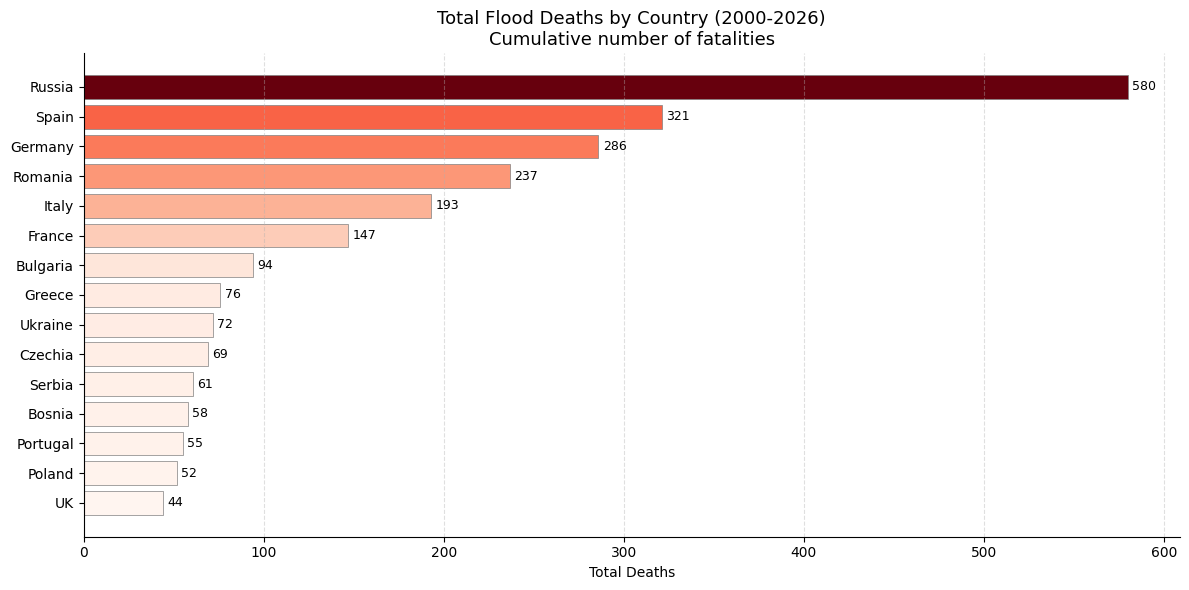

In [20]:
# Bar chart: Total flood deaths by country (top 15)
plot_ranked_barh(deaths_by_country, "Total Flood Deaths by Country (2000-2026)\nCumulative number of fatalities", "Total Deaths", "../images/06_deaths_by_country.png", cmap=cm.Reds, value_fmt="{:.0f}");

Russia and Spain record the highest cumulative flood mortality, despite suffering considerably lower economic losses than Germany or the UK. This inverse relationship between economic damage and mortality points to differences in resilience, early warning systems and emergency response capacity.

Spain's high death toll is largely driven by flash flood events, including the devastating 2024 DANA event which alone caused 232 deaths. Flash floods are particularly lethal because they leave little time for evacuation, and their impact is expected to intensify under climate change.

Eastern European countries such as Romania and Bulgaria also show disproportionately high mortality relative to their economic losses, suggesting lower adaptive capacity and infrastructure resilience.

## Population Impact Analysis

Beyond fatalities, how many people are affected by floods in each country, and how does this compare to economic damage?

Total People Affected by Floods by Country - Cumulative 2000-2026

In [21]:
# --- POPULATION IMPACT ANALYSIS ---

# Total people affected by floods, by country (top 15)
# "Total Affected" combines injured, affected and homeless (EM-DAT definition)
affected_by_country = (
    df_clean.groupby("country")["total_affected"]
.sum(min_count=1)
.dropna()
.sort_values(ascending=False)
.head(15))

display(affected_by_country.astype(int).to_frame(name="Total People Affected"))

,Total People Affected
country,
Russia,2705808
Bosnia,1616099
Czechia,1520489
Slovenia,1520020
Ukraine,641044
UK,486703
Germany,344315
Romania,303270
North Macedonia,253376


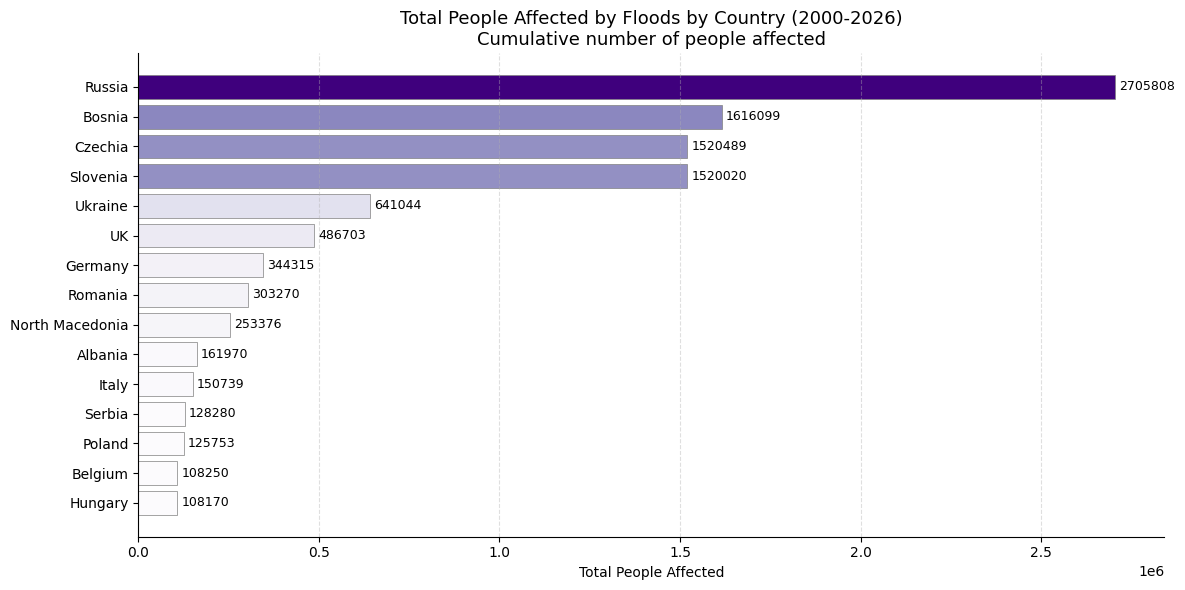

In [22]:
# Bar chart: total people affected by floods (top 15)
plot_ranked_barh(affected_by_country, "Total People Affected by Floods by Country (2000-2026)\nCumulative number of people affected", "Total People Affected", "../images/12_affected_by_country.png", cmap=cm.Purples, value_fmt="{:.0f}");

Looking beyond fatalities and economic damage, the number of people affected tells a different story about flood impact. Russia leads by a wide margin (2.7 million people affected), consistent with its large population and geography, but Bosnia  stands out with 1.6 million people affected despite not ranking among the top 15 countries by economic damage. Czechia and Slovenia also rank far higher here than in the damage tables.

This divergence suggests that economic damage figures - which depend on insured assets and formal loss reporting - can understate the human scale of flood events in countries with lower asset values or less complete economic reporting. For humanitarian planning and disaster preparedness, population affected is arguably a more direct indicator of the need for emergency response capacity than monetary loss alone.

## Vulnerability Analysis

**Do countries with higher economic losses also record higher mortality, or are there countries with disproportionately high death tolls relative to their damage?**

In [ ]:
# --- VULNERABILITY ANALYSIS ---

# Filter to countries with enough independent events to support a reliable
# damage/mortality profile. Using a magnitude threshold (e.g. "damage > $1B")
# is circular: it picks which countries appear based on the very variables
# being plotted, biasing the chart toward countries already known to be large.
# A data-volume threshold (>=3 recorded events for each metric) filters for
# statistical reliability instead, regardless of whether the resulting total
# is big or small.
vulnerability = df_clean.groupby("country").agg(
    total_damage_b=("total_damage_adj", lambda x: x.sum() / 1e6),
    total_deaths=("total_deaths", "sum"),
    n_damage_events=("total_damage_adj", lambda x: x.notna().sum()),
    n_death_events=("total_deaths", lambda x: x.notna().sum()),
).dropna().query("total_deaths > 0 and total_damage_b > 0")

vulnerability_filtered = vulnerability[
    (vulnerability["n_damage_events"] >= 3) & (vulnerability["n_death_events"] >= 3)
]

In [ ]:
# --- VULNERABILITY ANALYSIS ---

# Cross analysis: economic damage vs mortality by country
# Countries with high deaths but low damage may indicate lower resilience

fig, ax = plt.subplots(figsize=(12, 7))

norm = plt.Normalize(vulnerability_filtered["total_damage_b"].min(), 
                     vulnerability_filtered["total_damage_b"].max())
colors = cm.YlOrRd(norm(vulnerability_filtered["total_damage_b"].values))

ax.scatter(
    vulnerability_filtered["total_damage_b"],
    vulnerability_filtered["total_deaths"],
    color=colors, alpha=0.8, s=120, edgecolor="gray", linewidth=0.5
)

for country, row in vulnerability_filtered.iterrows():
    
    if country == "Switzerland":
        xytext = (6, -12)
    elif country == "Slovenia":
        xytext = (6, 8)
    else:
        xytext = (6, 4)
        
    ax.annotate(country, (row["total_damage_b"], row["total_deaths"]),
                fontsize=9, textcoords="offset points", xytext=xytext)

median_damage = vulnerability_filtered["total_damage_b"].median()
median_deaths = vulnerability_filtered["total_deaths"].median()

ax.axvline(median_damage, color="gray", linestyle=":", linewidth=1.2, zorder=0)
ax.axhline(median_deaths, color="gray", linestyle=":", linewidth=1.2, zorder=0)

ax.set_xscale("log")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_title("Flood Risk: Economic Damage vs Mortality by Country (2000-2026)\nCountries with \u2265 3 recorded damage events and \u2265 3 recorded death events", fontsize=13)
ax.set_xlabel("Total Adjusted Damage (Billion USD, log scale)")
ax.set_ylabel("Total Deaths")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(linestyle="--", alpha=0.4)

median_line = Line2D([0], [0], color="gray", linestyle=":", linewidth=1.2, label="Median (damage / deaths)")
ax.legend(handles=[median_line], loc="lower right", fontsize=9)

plt.savefig("../images/07_vulnerability_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

The scatter plot reveals distinct risk profiles among European countries. The dashed grey lines mark the median total damage and median death toll within this filtered set of countries, dividing the chart into four quadrants. Countries are included here based on data volume (at least 3 recorded events for both damage and deaths), not on the size of their totals, so the country set is chosen independently of the story it ends up telling.

Countries in the upper-left quadrant - damage below the median but mortality above it - include Bulgaria, Greece, Romania and Ukraine. These countries show high mortality relative to economic losses, suggesting lower resilience and adaptive capacity, where floods cause significant human casualties despite relatively limited recorded economic damage.

Countries in the lower-right quadrant - damage above the median but mortality below it - include the UK, Austria, Czechia and Poland. These countries show the opposite pattern: high economic losses but comparatively lower mortality, reflecting stronger emergency response systems and early warning infrastructure, alongside higher asset exposure.

Germany, Italy, Spain, France and Russia all fall in the upper-right quadrant, combining both high economic losses and high mortality. Dual vulnerability - high exposure combined with limited resilience or insurance coverage - is therefore not unique to Italy: based on the medians used here, it is in fact the most common profile among the larger European economies in this dataset.

The remaining countries - Albania, Bosnia, North Macedonia, Serbia, Slovakia and Slovenia - fall in the lower-left quadrant, below the median on both axes. Bosnia sits here rather than in the high-mortality quadrant purely because the comparison group changed: its own damage and death totals are unchanged, but the countries it is now benchmarked against (Albania, North Macedonia and Slovakia, each supported by 3+ recorded events) have a materially lower median than the previous, magnitude-filtered set did. North Macedonia is worth flagging specifically: 32 deaths across 4 recorded events is not a data fluke, and it would have been excluded entirely under the previous >50-deaths threshold despite having a genuine, multi-event mortality profile.

## Flood Type Analysis

**Which type of flood causes the most economic damage and the highest mortality in Europe?**

**Flood Type Analysis - Europe 2000-2026**

In [25]:
# --- FLOOD TYPE ANALYSIS ---

# Economic damage and deaths by flood subtype
flood_type_analysis = df_clean.groupby("flood_type").agg(
    total_events=("flood_type", "count"),
    total_damage_b=("total_damage_adj", lambda x: x.sum() / 1e6),
    total_deaths=("total_deaths", "sum"),
    events_with_damage=("total_damage_adj", lambda x: x.notna().sum()),
    events_with_deaths=("total_deaths", lambda x: x.notna().sum())
).round(1)

flood_type_analysis["Damage Coverage"] = (flood_type_analysis["events_with_damage"] / flood_type_analysis["total_events"]).map("{:.0%}".format)
flood_type_analysis["Deaths Coverage"] = (flood_type_analysis["events_with_deaths"] / flood_type_analysis["total_events"]).map("{:.0%}".format)

flood_type_analysis = flood_type_analysis.rename(columns={
    "total_events": "Total Events",
    "total_damage_b": "Total Damage (B USD)",
    "total_deaths": "Total Deaths",
    "events_with_damage": "Events with Damage Data",
    "events_with_deaths": "Events with Deaths Data"
})

display(flood_type_analysis)

,Total Events,Total Damage (B USD),Total Deaths,Events with Damage Data,Events with Deaths Data,Damage Coverage,Deaths Coverage
flood_type,,,,,,,
Coastal flood,5,0.9,13.0,4,2,80%,40%
Flash flood,102,15.7,606.0,37,61,36%,60%
Flood (General),105,105.1,786.0,29,45,28%,43%
Riverine flood,281,122.6,1094.0,110,164,39%,58%


**Note on the "Flood (General)" category**

"Flood (General)" is an EM-DAT classification applied when a flood event is not assigned to a more specific subtype (riverine, flash or coastal). It does not describe a distinct physical flood mechanism, and events grouped here may share characteristics with riverine or flash floods depending on how the source report described them.

This matters for interpretation: "Flood (General)" ranks 2nd by total damage (105.1B USD, close to Riverine flood) and has the highest average deaths per event (7.49) of the four categories, yet it is easy to overlook since it is not a well-known hazard label like "flash flood". Its damage total is also heavily concentrated in a single extreme event - the 2021 Ahr Valley floods - as the breakdown below shows.

In [26]:
# --- FLOOD (GENERAL) OUTLIER CHECK ---
# Isolate the 2021 Ahr Valley event within the "Flood (General)" category
flood_general = df_clean[df_clean["flood_type"] == "Flood (General)"]
ahr_valley_mask = (flood_general["country"] == "Germany") & (flood_general["year"] == 2021)

damage_with_outlier = flood_general["total_damage_adj"].sum(min_count=1) / 1e6
damage_without_outlier = flood_general.loc[~ahr_valley_mask, "total_damage_adj"].sum(min_count=1) / 1e6
events_with_outlier = len(flood_general)
events_without_outlier = len(flood_general) - ahr_valley_mask.sum()

outlier_check = pd.DataFrame({"Scenario": ["Flood (General) - all events", "Flood (General) - excluding Ahr Valley 2021"], "Events": [events_with_outlier, events_without_outlier], "Total Damage (B USD)": [round(damage_with_outlier, 1), round(damage_without_outlier, 1)]})

display(outlier_check)

print(f"\nThe Ahr Valley 2021 event alone represents {(damage_with_outlier - damage_without_outlier) / damage_with_outlier:.0%} of the total damage attributed to the 'Flood (General)' category.")

,Scenario,Events,Total Damage (B USD)
0,Flood (General) - all events,105,105.1
1,Flood (General) - excluding Ahr Valley 2021,104,57.5



The Ahr Valley 2021 event alone represents 45% of the total damage attributed to the 'Flood (General)' category.


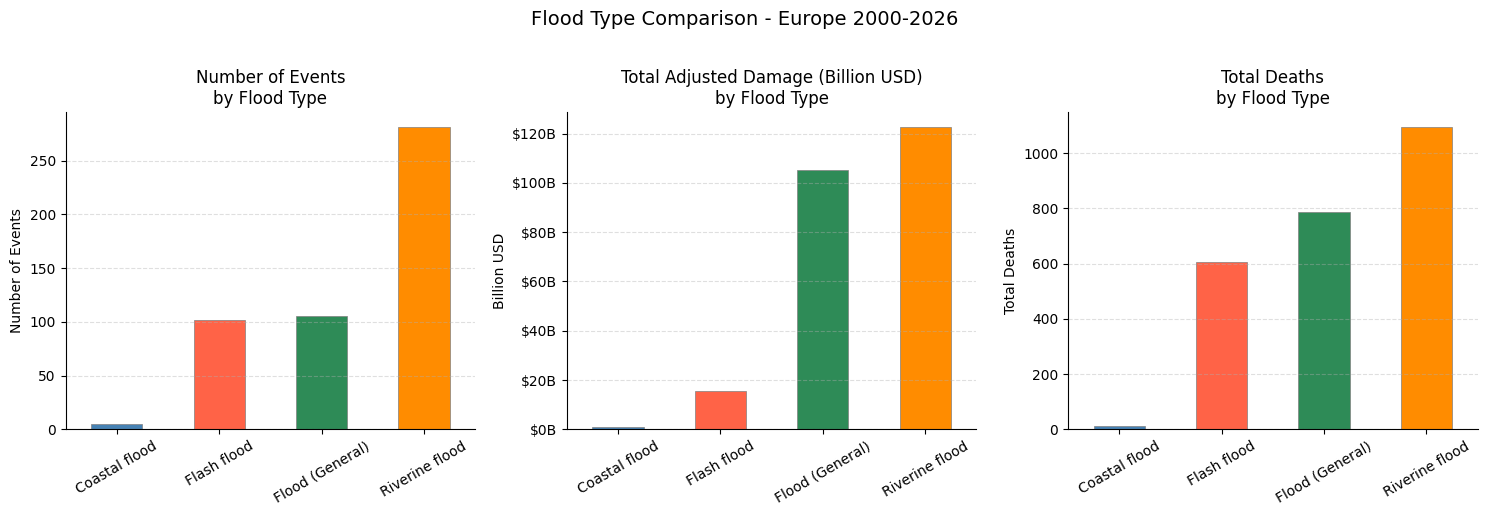

In [27]:
# --- FLOOD TYPE VISUALIZATION ---

# Bar charts: events, damage and deaths by flood type
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["steelblue", "tomato", "seagreen", "darkorange"]

# Events
flood_type_analysis["Total Events"].plot(
    kind="bar", ax=axes[0], color=colors, edgecolor="gray", linewidth=0.5
)
axes[0].set_title("Number of Events\nby Flood Type", fontsize=12)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Events")
axes[0].tick_params(axis="x", rotation=30)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Damage
flood_type_analysis["Total Damage (B USD)"].plot(
    kind="bar", ax=axes[1], color=colors, edgecolor="gray", linewidth=0.5
)
axes[1].set_title("Total Adjusted Damage (Billion USD)\nby Flood Type", fontsize=12)
axes[1].set_xlabel("")
axes[1].set_ylabel("Billion USD")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
axes[1].tick_params(axis="x", rotation=30)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

# Deaths
flood_type_analysis["Total Deaths"].plot(
    kind="bar", ax=axes[2], color=colors, edgecolor="gray", linewidth=0.5
)
axes[2].set_title("Total Deaths\nby Flood Type", fontsize=12)
axes[2].set_xlabel("")
axes[2].set_ylabel("Total Deaths")
axes[2].tick_params(axis="x", rotation=30)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Flood Type Comparison - Europe 2000-2026", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../images/08_flood_type_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Riverine floods dominate in both frequency and cumulative economic damage, making them the primary driver of aggregate losses in Europe. However, flash floods stand out for their disproportionate lethality: with fewer events and lower total damage, they account for a significant share of total deaths.

This distinction matters for risk modelling. Riverine floods are relatively predictable and slower-moving, allowing time for evacuation and response. Flash floods, by contrast, develop rapidly and with little warning, making them far more dangerous per event. Under climate change, both types are expected to intensify, but flash floods are projected to increase in frequency in Southern Europe, where the 2024 DANA event in Spain provided a stark illustration of their destructive potential.

Coastal floods remain rare in the dataset but should not be underestimated. Rising sea levels and more intense storm surges are expected to increase both frequency and severity in low-lying coastal areas across Northern and Western Europe.

It is also worth flagging "Flood (General)" separately here, since it does not fit neatly into the riverine/flash narrative above. It ranks 2nd by total damage (105.1B USD) and records the highest average deaths per event of all four categories, but this reflects an EM-DAT catch-all label rather than a distinct hazard mechanism, and its damage figure is dominated by a single event, the 2021 Ahr Valley floods (see note and breakdown earlier in this section). Comparisons across flood types should therefore treat this category with more caution than the others.

## Mortality by Flood Type

**Which flood type is the deadliest per event?**

**Mortality by Flood Type - Europe 2000-2026**

In [28]:
# --- MORTALITY BY FLOOD TYPE ---

# Average deaths per event by flood type
mortality_by_type = df_clean.groupby("flood_type").agg(
    total_events=("flood_type", "count"),
    total_deaths=("total_deaths", lambda x: x.sum(min_count=1)),
).round(1)
mortality_by_type["avg_deaths_per_event"] = (
    mortality_by_type["total_deaths"] / mortality_by_type["total_events"]
).round(2)

mortality_by_type["total_deaths"] = mortality_by_type["total_deaths"].astype(int)

display(mortality_by_type.rename(columns={
    "total_events": "Total Events",
    "total_deaths": "Total Deaths",
    "avg_deaths_per_event": "Avg Deaths per Event"
}))

,Total Events,Total Deaths,Avg Deaths per Event
flood_type,,,
Coastal flood,5,13,2.60
Flash flood,102,606,5.94
Flood (General),105,786,7.49
Riverine flood,281,1094,3.89


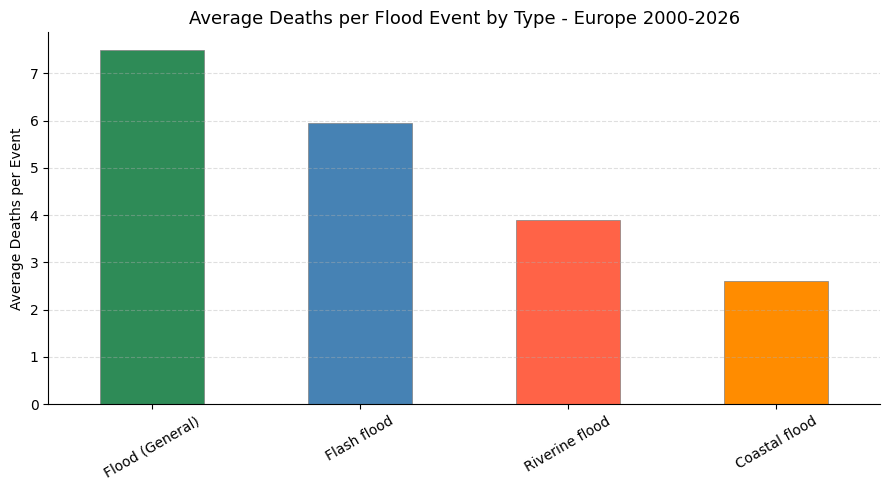

In [29]:
# Bar chart: average deaths per event by flood type

fig, ax = plt.subplots(figsize=(9, 5))

mortality_by_type["avg_deaths_per_event"].sort_values(ascending=False).plot(
    kind="bar", ax=ax, color=["seagreen", "steelblue", "tomato", "darkorange"], edgecolor="gray", linewidth=0.5
)

ax.set_title("Average Deaths per Flood Event by Type - Europe 2000-2026", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Average Deaths per Event")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../images/09_mortality_by_flood_type.png", dpi=150)
plt.show()

Flash floods and Flood (General) events record the highest average deaths per event, reinforcing the finding that frequency alone is not a reliable indicator of risk. Riverine floods, despite being the most frequent and economically costly, cause fewer deaths per event due to their slower onset and greater predictability.

Note on Coastal flood mortality: the 2.60 deaths/event average for this category is based on only 2 events with recorded death data (40% coverage, out of just 5 Coastal flood events total). This is too small a sample to support meaningful comparison with Flash flood or Riverine flood, whose mortality rates are based on 61 and 164 death-recorded events respectively. Coastal flood mortality should therefore be treated as indicative at best, not as a reliable estimate.

This has direct implications for emergency management and adaptation policy: investing in early warning systems and evacuation protocols for flash floods should be prioritised, particularly in Southern and Eastern Europe where both frequency and lethality are highest.

## Extreme Events

**Which individual flood events have caused the greatest economic losses in Europe since 2000?**

**Top 10 Most Costly Flood Events in Europe 2000-2026** (Billion USD adjusted)

In [30]:
# --- EXTREME EVENTS ANALYSIS ---
# Top 10 most costly individual flood events in Europe (2000-2026)
top_damage_events = (
    df_clean[df_clean["total_damage_adj"].notna()]
    .nlargest(10, "total_damage_adj")
    [["country", "year", "month", "flood_type", "total_damage_adj", "insured_damage_adj", "total_deaths"]]
    .copy()
)
top_damage_events["total_damage_b"] = (top_damage_events["total_damage_adj"] / 1e6).round(1)
top_damage_events["insured_damage_b"] = (top_damage_events["insured_damage_adj"] / 1e6).round(1)
top_damage_events["total_deaths"] = top_damage_events["total_deaths"].fillna(0).astype(int)

display_cols = top_damage_events[["country", "year", "month", "flood_type", "total_damage_b", "insured_damage_b", "total_deaths"]].copy()
display_cols.columns = ["Country", "Year", "Month", "Flood Type", "Total Damage (B USD)", "Insured (B USD)", "Deaths"]
display_cols["Insured (B USD)"] = display_cols["Insured (B USD)"].fillna("N/A")

display(display_cols.reset_index(drop=True))

,Country,Year,Month,Flood Type,Total Damage (B USD),Insured (B USD),Deaths
0,Germany,2021,7,Flood (General),47.5,11.5,226
1,Germany,2002,8,Flood (General),20.8,3.2,27
2,Germany,2013,5,Riverine flood,17.8,2.5,4
3,Italy,2000,10,Riverine flood,15.0,0.6,25
4,Spain,2024,10,Flood (General),11.3,4.3,232
5,UK,2000,10,Riverine flood,11.0,0.1,3
6,Italy,2023,5,Flood (General),10.3,N/A,15
7,UK,2007,6,Riverine flood,6.2,4.7,6
8,UK,2007,7,Riverine flood,6.2,4.7,7
9,Germany,2024,5,Flood (General),4.6,2.1,12


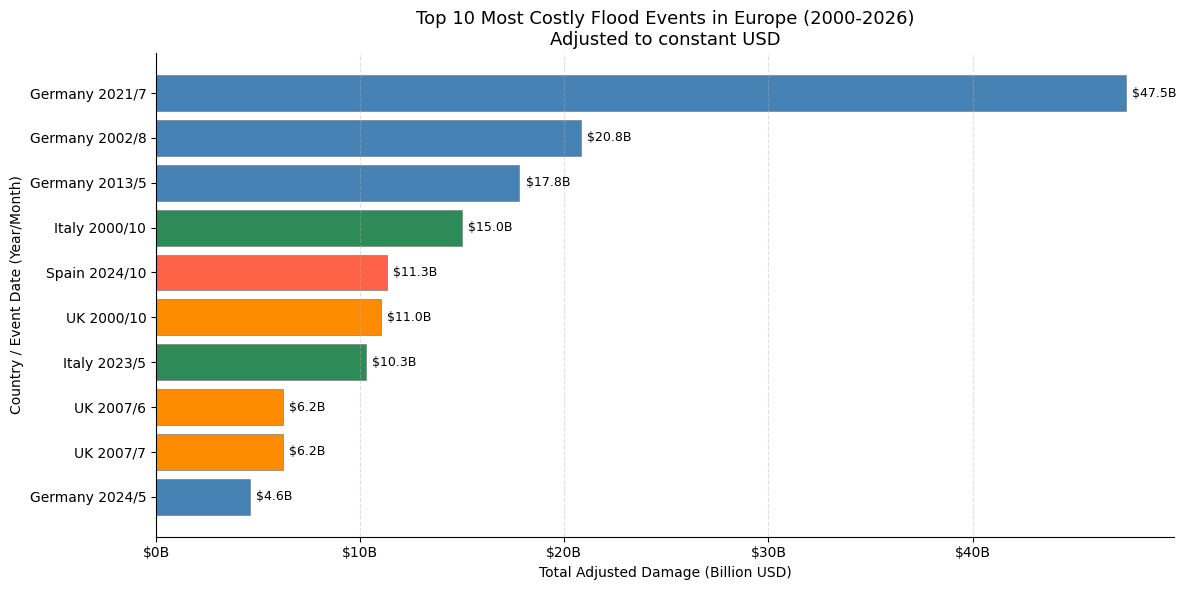

In [31]:
# Bar chart: Top 10 most costly flood events
fig, ax = plt.subplots(figsize=(12, 6))

labels = [f"{row.Country} {row.Year}/{row.Month}" for row in display_cols.itertuples()]
colors_map = {"Germany": "steelblue", "Italy": "seagreen", "Spain": "tomato", "UK": "darkorange"}
bar_colors = [colors_map.get(row.Country, "gray") for row in display_cols.itertuples()]

ax.barh(labels[::-1], display_cols["Total Damage (B USD)"][::-1], color=bar_colors[::-1], edgecolor="gray", linewidth=0.5)

# Value labels
for i, value in enumerate(display_cols["Total Damage (B USD)"][::-1]):
    ax.text(value + 0.3, i, f"${value}B", va="center", fontsize=9)

ax.set_title("Top 10 Most Costly Flood Events in Europe (2000-2026)\nAdjusted to constant USD", fontsize=13)
ax.set_xlabel("Total Adjusted Damage (Billion USD)")
ax.set_ylabel("Country / Event Date (Year/Month)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0f}B"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../images/10_top_events.png", dpi=150)
plt.show()

The top 10 most costly flood events reveal a clear pattern: a small number of catastrophic events account for a disproportionate share of total losses. The 2021 Ahr Valley floods in Germany alone represent nearly 20% of all recorded flood damage across Europe over 26 years.

Germany appears four times in the top 10, confirming its outsized exposure to extreme flood events. The Spain 2024 DANA event is notable for combining significant economic losses with the highest death toll in the dataset, highlighting the dual economic and humanitarian cost of flash floods.

Italy 2023 stands out for having no insured damage recorded, despite 10.3B USD in total losses. This is a stark example of the insurance protection gap in action.

## Geographic Analysis

**How is flood economic damage distributed across European countries?**

In [32]:
# --- GIS MAP: FLOOD DAMAGE BY COUNTRY ---
# Aggregate total adjusted damage by country ISO code
damage_map = (
    df_clean.groupby("iso")["total_damage_adj"]
    .sum(min_count=1)
    .reset_index()
)
damage_map.columns = ["iso", "total_damage_adj"]
damage_map["total_damage_b"] = (damage_map["total_damage_adj"] / 1e6).round(2)

# Download world shapefile from Natural Earth
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
zip_path = "../data/external/ne_110m_admin_0_countries.zip"
shp_dir = "../data/external/ne_110m_admin_0_countries"

if not os.path.exists(shp_dir):
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(shp_dir)

world = geopandas.read_file(f"{shp_dir}/ne_110m_admin_0_countries.shp")

# Filter Europe and merge with damage data
europe_map = world[world["CONTINENT"] == "Europe"].merge(
    damage_map, left_on="ADM0_A3", right_on="iso", how="left"
)

print(f"Countries in map: {len(europe_map)}")
print("\nTop 10 countries by total adjusted flood damage (Billion USD):")
display(europe_map[["NAME", "ADM0_A3", "total_damage_b"]].dropna().sort_values("total_damage_b", ascending=False).head(10).reset_index(drop=True).rename(columns={"NAME": "Country", "ADM0_A3": "ISO", "total_damage_b": "Total Damage (B USD)"}))

Countries in map: 39

Top 10 countries by total adjusted flood damage (Billion USD):


,Country,ISO,Total Damage (B USD)
0,Germany,DEU,93.81
1,United Kingdom,GBR,34.34
2,Italy,ITA,32.05
3,Spain,ESP,16.65
4,France,FRA,15.76
5,Austria,AUT,7.13
6,Czechia,CZE,6.37
7,Poland,POL,5.97
8,Russia,RUS,5.47
9,Romania,ROU,4.36


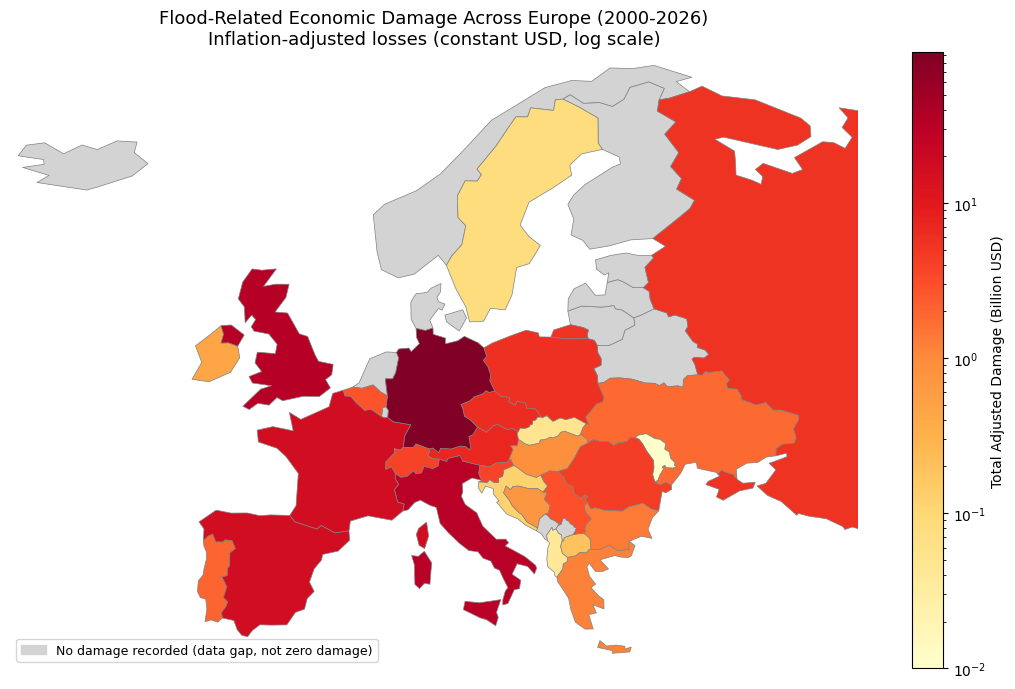

In [33]:
# --- CHOROPLETH MAP: FLOOD DAMAGE BY COUNTRY ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot countries without data in light grey
europe_map[europe_map["total_damage_b"].isna()].plot(
    ax=ax, color="lightgrey", edgecolor="gray", linewidth=0.5
)

# Filter only countries with damage > 0 for log scale
europe_with_damage = europe_map[europe_map["total_damage_b"] > 0].copy()

# Plot countries with data using color scale
europe_with_damage.plot(
    ax=ax,
    column="total_damage_b",
    cmap="YlOrRd",
    edgecolor="gray",
    linewidth=0.5,
    legend=True,
    norm=LogNorm(
        vmin=europe_with_damage["total_damage_b"].min(),
        vmax=europe_with_damage["total_damage_b"].max()
    ),
    legend_kwds={"label": "Total Adjusted Damage (Billion USD)", "orientation": "vertical"}
)

# Zoom into Western/Central Europe
ax.set_xlim(-25, 45)
ax.set_ylim(34, 72)

ax.set_title("Flood-Related Economic Damage Across Europe (2000-2026)\nInflation-adjusted losses (constant USD, log scale)", fontsize=13)
ax.set_axis_off()

grey_patch = mpatches.Patch(color="lightgrey", label="No damage recorded (data gap, not zero damage)")
ax.legend(handles=[grey_patch], loc="lower left", fontsize=9)

plt.savefig("../images/11_flood_damage_map.png", dpi=300, bbox_inches="tight")
plt.show()

The choropleth map confirms the geographic concentration of flood losses across Europe. Western and Central Europe, particularly Germany, the UK, Italy and France, account for the majority of recorded economic damage, reflecting both high asset exposure and the frequency of major flood events in these regions.

Eastern European countries such as Ukraine show lower recorded losses, which may partly reflect underreporting rather than lower actual exposure. Belarus and Finland have no damage data recorded in the dataset and therefore both appear in grey on the map - this reflects a data gap, not confirmed low exposure. Sweden, which does have one small recorded event (0.08B USD), likely benefits from different hydrological conditions and fewer extreme flood events historically, though a single data point should not be over-interpreted.

The spatial pattern underlines the uneven distribution of flood risk across Europe and the importance of country-level risk differentiation in insurance pricing, catastrophe modelling and climate adaptation planning.

## Business and Policy Implications

**For insurers and reinsurers:**
- Germany, Italy and the UK may warrant prioritisation for flood risk capital allocation, though these figures reflect only reported losses and should be interpreted alongside data coverage rates.
- Insurance data coverage in Eastern Europe is low (Romania: 0%, Russia: 4%, Poland: 10%), meaning apparent underinsurance may partly reflect reporting gaps rather than confirmed absence of coverage.
- Flash floods require separate modelling frameworks due to their high mortality rate per event.

**For governments and regulators:**
- The large insurance protection gap across Europe supports the case for mandatory flood insurance schemes.
- Eastern European countries show higher mortality relative to economic losses, suggesting lower resilience and a need for targeted adaptation investment.
- TCFD physical risk disclosures should require companies to assess exposure to all four flood subtypes.

**For investors and asset managers:**
- Flood risk is increasingly concentrated in a small number of catastrophic events, making tail risk assessment critical.
- Climate change is expected to intensify flash floods and coastal floods, requiring dynamic risk models that go beyond historical data.

## Key Findings and Climate Risk Implications

### Economic Losses
- Germany accounts for the largest cumulative flood losses in Europe (93.8B USD adjusted), driven primarily 
  by the 2021 Ahr Valley floods (47.5B USD), one of the costliest natural disasters in European history.
- The top 3 countries (Germany, UK, Italy) represent approximately 66% (65.6%) of total recorded flood damage across all 27 countries with damage data in Europe.

### Insurance Protection Gap
- Italy shows the largest relative protection gap within the insurance-matched subset: only 5% of flood damage was insured (0.9B of 17.2B USD; this subset's total differs from the 32B USD figure used in the Exploratory Analysis section - see the Insurance Gap Analysis note).
- Romania has no insured damage recorded for any of its 44 events (not a near-zero value, but a complete absence of data), though this likely reflects a reporting gap rather than confirmed absence of insurance coverage.
- Even in Germany, 78% of flood losses were uninsured (73.3B USD gap), highlighting systemic underinsurance 
  across Europe despite relatively developed insurance markets.

### Mortality and Vulnerability
- Russia and Spain recorded the highest flood mortality (580 and 321 deaths respectively), 
  despite lower economic losses than Germany or the UK, suggesting lower resilience and adaptive capacity.
- The Spain 2024 DANA event (232 deaths, 11.3B USD damage) demonstrates the growing lethality of flash floods 
  under climate change.
-   Slovenia illustrates a compounding vulnerability profile: it has the highest flood damage relative to GDP of any country in this dataset (8.42%, GDP Normalisation section) and ranks 4th by total population affected (1.52 million, Population Impact Analysis section) - disproportionate for a country that ranks only 12th by absolute economic damage ($3.85B).

### Flood Type Risk Profile
- Riverine floods dominate in frequency (281 events) and cumulative damage (122.6B USD).
- Flood (General) technically records the highest mortality rate per event (7.49 deaths/event), though this reflects an EM-DAT catch-all category rather than a distinct hazard mechanism. Among the named hazard types, flash floods show the highest mortality rate (5.94 deaths/event) and are highlighted here as consistent with IPCC AR6 projections of increasing flash flood intensity under climate change scenarios.
- Coastal floods remain rare (5 events) but are projected to intensify significantly under sea level rise.

### Relevance for Climate Risk Frameworks
- These findings are directly relevant to TCFD physical risk disclosure requirements.
- The insurance protection gap data supports the case for mandatory flood insurance schemes 
  currently under discussion at EU regulatory level.
- Catastrophe modelling frameworks (RMS, AIR) should weight Germany, Italy and the UK as 
  highest-priority markets for flood risk capital allocation.

## Climate Risk Perspective

Although EM-DAT provides historical disaster records rather than probabilistic climate projections, historical flood impacts remain an essential input for physical climate risk assessment. The patterns identified above - historical exposure, vulnerability and economic losses - support risk prioritisation for insurers, investors and infrastructure planners.

The findings can be organised using the Hazard - Exposure - Vulnerability framework commonly used in climate risk assessment:

- **Hazard**: the flood event itself, differentiated by subtype - river flood, flash flood and coastal flood - each with a distinct intensity, speed of onset and geographic footprint.
- **Exposure**: the economic assets located in flood-prone areas, approximated here through total damage, insured damage and GDP normalisation.
- **Vulnerability**: the susceptibility of people and systems once exposed, reflected in fatalities, affected population and the size of the insurance protection gap.

A simplified representation of this chain:

`Hazard -> Exposure -> Vulnerability -> Economic Loss`

Applying this framework to the flood subtypes analysed above gives an illustrative risk profile:

| Flood Type | Hazard (frequency) | Exposure (economic damage) | Vulnerability (mortality per event) |
|---|---|---|---|
| Riverine flood | Very High | High | Medium |
| Flash flood | Medium | Medium | Very High |
| Coastal flood | Low (currently) | Low (currently) | Low (currently) |

*Ratings are illustrative, based on the relative frequency, damage and mortality patterns observed in this dataset (2000-2026), rather than on an external catastrophe model.*

## Conclusions

These conclusions draw on EM-DAT records where damage and insurance data were reported - only 37% of events include economic damage figures and 10% include insured damage figures (see Limitations below). Findings on economic losses and insurance gaps should be read as patterns within the reported subset, not as complete measures of total flood impact.

- Flood losses in Europe are increasingly concentrated in a small number of catastrophic events rather than distributed evenly across years (based on the reported subset of events with damage data).
- Western Europe suffers the largest economic damage due to high asset exposure, but Eastern Europe bears a disproportionate human cost relative to recorded losses.
- The insurance protection gap remains a systemic problem across Europe, even in developed markets like Germany and France (based on the reported subset of events with insurance data).
- Flash floods show the highest mortality rate per event among the named hazard types (5.94 deaths/event) and are projected to intensify under climate change, particularly in Southern Europe; note that "Flood (General)", an EM-DAT catch-all category, records an even higher rate (7.49 deaths/event) but is not a distinct hazard mechanism (see Flood Type Analysis).
- Climate adaptation policies should consider both economic exposure and human vulnerability rather than focusing solely on aggregate loss statistics.
- When normalised by GDP, smaller economies such as Slovenia and Serbia show disproportionately high flood exposure relative to their economic size, challenging conclusions based solely on absolute loss figures.
- Historical disaster databases cannot predict future flood events, but they provide valuable evidence for identifying vulnerable regions and supporting physical climate risk assessment.
- Combining historical losses with forward-looking climate projections represents the next step for comprehensive climate risk modelling.

## Limitations and Future Work

**Limitations:**
- EM-DAT relies on reported data, which introduces reporting lag bias, particularly for recent years and smaller events.
- Economic damage figures are incomplete: only 37% of events have recorded damage data.
- Insured damage data is available for only 10% of events, limiting the precision of insurance gap estimates.
- Reported losses in EM-DAT depend on national reporting practices and may underestimate the economic impact of smaller events, introducing uncertainty into cross-country comparisons.
- The "Damage as % of Average GDP" metric (GDP Normalisation section) divides cumulative damage accumulated over 27 years (2000-2026) by a single-year average GDP (2000-2024). This is a cumulative-to-single-year ratio, not an annualised loss rate, and should not be read as "X% of GDP lost per year" - it is a rough indicator of relative economic exposure over the full period, not an annual rate.
- The declining linear trend in flood event frequency (Trend Analysis section) has a low R² (0.227), meaning the year of occurrence explains only about 23% of the variance in event counts, despite a statistically significant p-value (0.016). This trend should be read as weak and should not be over-interpreted as a strong or reliable signal of declining flood frequency.

**Future Work:**
- Integrate Copernicus flood hazard layers to complement historical event records with modelled hazard extent.
- Incorporate floodplain exposure datasets to refine asset-level exposure estimates beyond national aggregates.
- Analyse critical infrastructure exposure (energy, transport, healthcare) in high-risk river basins.
- Compare historical losses with CMIP6 climate projections to assess how hazard patterns may evolve.
- Develop a spatial flood risk index combining hazard, exposure and vulnerability at sub-national level.